# Applying Central Limit Theorem with Simulations

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply Central Limit Theorem with simulations
- Understand how sample means converge to normal distribution
- Visualize CLT with different sample sizes and distributions
- Demonstrate CLT with real examples

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 01 "03. Learning under Uncertainty" — why sampling variation is unavoidable; the CLT says what shape that variation takes.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Applying Central Limit Theorem with simulations

---

## Introduction

**Central Limit Theorem (CLT)** states that the distribution of sample means approaches a normal distribution as sample size increases, regardless of the original population distribution.


---

## 📌 Real case: the theorem that holds, and the tails that do not

Almost everything you will ever report — an average accuracy, an average response time, an A/B test's lift —
relies on the Central Limit Theorem. It is the reason a sample mean has a predictable distribution even when
the underlying data does not, and therefore the reason a confidence interval means anything at all.

It is also routinely stretched past where it applies. Long-Term Capital Management's risk models, built by a
team including two 1997 Nobel laureates in economics, assumed the well-behaved bell-shaped picture the CLT
promises. In 1998 the fund lost **$4.6 billion in under four months** and needed a **$3.6 billion** rescue
from fourteen banks. The historian Niall Ferguson's account of the flaw is exact: their models "implied
that the loss Long Term suffered in August was so unlikely that it ought never to have happened in the
entire life of the universe" — because they had been fitted to five years of data, none of it containing a
crisis.

**What goes wrong without this.** The CLT tells you about the *mean*. It says nothing about the largest
value, the worst day or the tail — and it converges slowly when the population is heavily skewed. The
experiment below shows exactly how slowly, on real, badly-behaved data: Titanic fares.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy for the resampling, Matplotlib for the histograms, scipy.stats for the
# reference normal curves, and the shared data loader for the REAL population we sample from.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("crime_statistics_original_50"), ...
# -------------------------------------------------------------------------------------


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nApplying Central Limit Theorem with Simulations")
print("=" * 60)


✅ Libraries imported!

Applying Central Limit Theorem with Simulations


## Part 1: CLT with Uniform Distribution


Part 1: CLT with a Real, Skewed Population
titanic: full file, 891 rows.

Original population: 891 real Titanic ticket fares (in 1912 pounds)
Population mean: 32.2042
Population std: 49.6655
Population skewness: 4.78  -> strongly right-skewed,
nothing like a bell curve: most passengers paid under 15 pounds, a few paid over 200.

Sample size 2:
  Mean of sample means: 32.3109
  Std of sample means: 36.0232
  Theoretical std (σ/√n): 35.1188
  Skewness of the sample means: 3.511

Sample size 5:
  Mean of sample means: 32.5470
  Std of sample means: 22.5430
  Theoretical std (σ/√n): 22.2111
  Skewness of the sample means: 2.125

Sample size 10:
  Mean of sample means: 32.0190
  Std of sample means: 15.5245
  Theoretical std (σ/√n): 15.7056
  Skewness of the sample means: 1.484

Sample size 30:
  Mean of sample means: 32.2393
  Std of sample means: 9.0730
  Theoretical std (σ/√n): 9.0676
  Skewness of the sample means: 0.860



Sample size 100:
  Mean of sample means: 32.1611
  Std of sample means: 4.9473
  Theoretical std (σ/√n): 4.9666
  Skewness of the sample means: 0.486


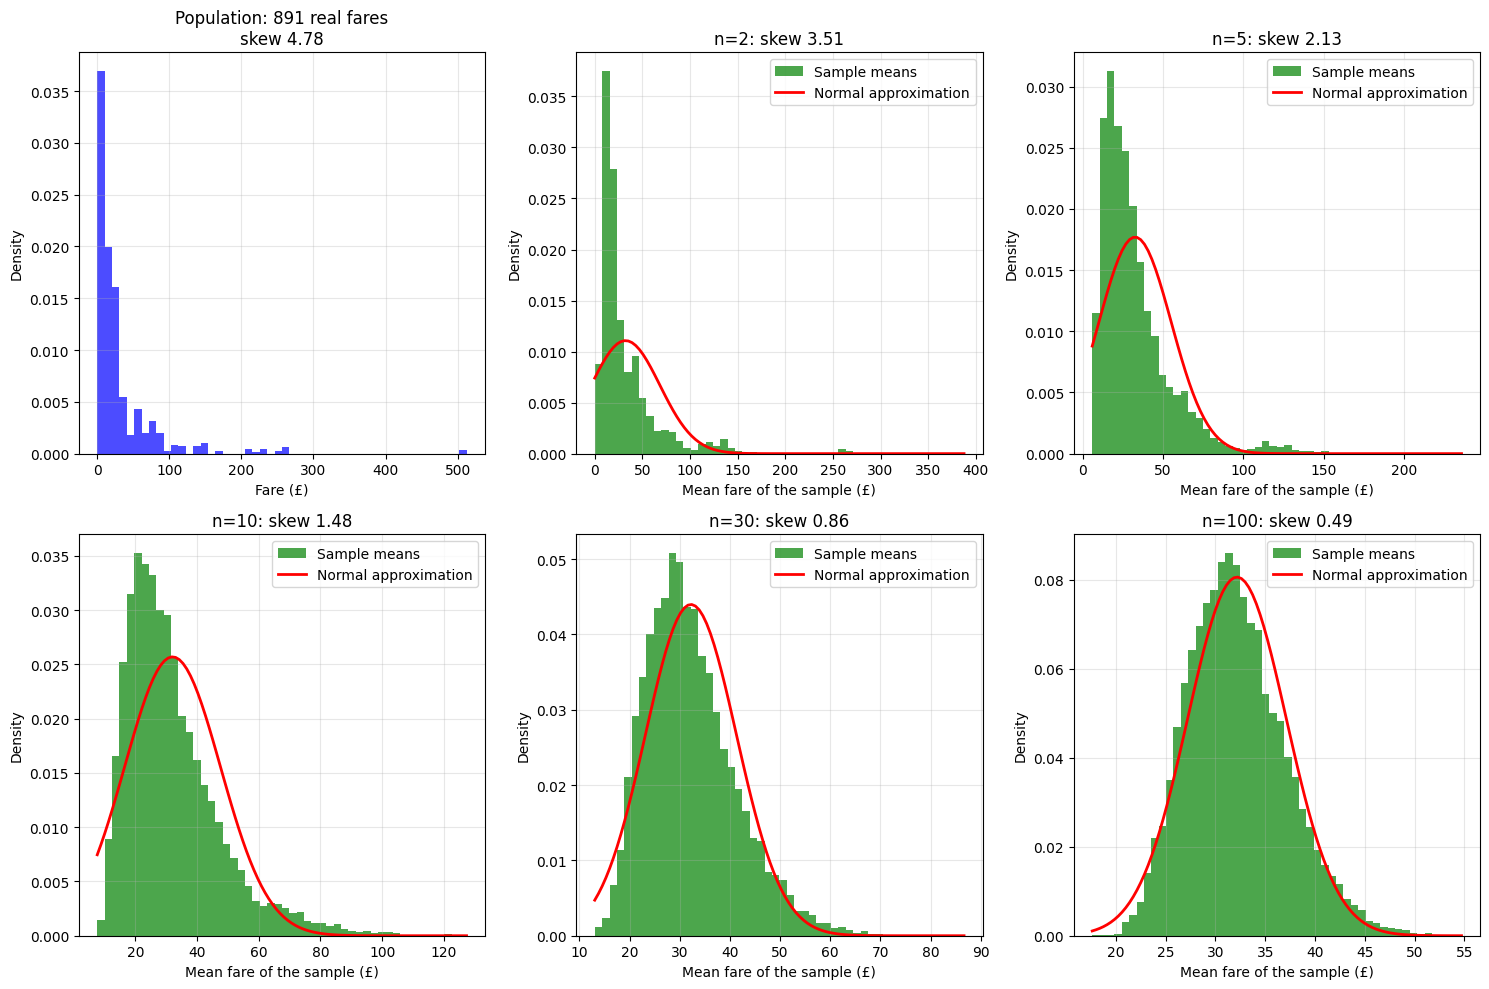


Read the skewness column, not just the pictures. The population's own skew is 4.78;
the sample means fall from 3.51 at n=2 to 0.49 at n=100.
That is the CLT working - and also its honest small print: with a population this
heavy-tailed, even n=100 has not reached a perfectly symmetric bell. The convergence
is real but gradual, which is why the usual 'n >= 30 is enough' rule is a guideline,
not a guarantee.

✅ CLT demonstrated on a real skewed population!


In [2]:
# Simulate the Central Limit Theorem on a REAL, badly-behaved population: the ticket fares
# actually paid by the 891 passengers on the Titanic. Draw many samples and histogram their means.
# As the sample size n grows, the means turn bell-shaped and their spread shrinks like sigma/sqrt(n).
#
# (np.random.choice here IS the lesson: repeated sampling is what the theorem is about.
#  The population itself is real - we did not invent a single fare.)

print("=" * 60)
print("Part 1: CLT with a Real, Skewed Population")
print("=" * 60)

np.random.seed(42)

titanic = load("titanic")
population = titanic["Fare"].dropna().to_numpy()

print(f"\nOriginal population: {len(population)} real Titanic ticket fares (in 1912 pounds)")
print(f"Population mean: {population.mean():.4f}")
print(f"Population std: {population.std():.4f}")
print(f"Population skewness: {stats.skew(population):.2f}  -> strongly right-skewed,")
print("nothing like a bell curve: most passengers paid under 15 pounds, a few paid over 200.")

# Simulate CLT with different sample sizes
sample_sizes = [2, 5, 10, 30, 100]
n_simulations = 10000

sample_means = {}
for n in sample_sizes:
    means = []
    for _ in range(n_simulations):
        sample = np.random.choice(population, size=n, replace=True)
        means.append(sample.mean())
    sample_means[n] = np.array(means)
    print(f"\nSample size {n}:")
    print(f"  Mean of sample means: {sample_means[n].mean():.4f}")
    print(f"  Std of sample means: {sample_means[n].std():.4f}")
    print(f"  Theoretical std (σ/√n): {population.std()/np.sqrt(n):.4f}")
    print(f"  Skewness of the sample means: {stats.skew(sample_means[n]):.3f}")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original population
axes[0, 0].hist(population, bins=50, density=True, alpha=0.7, color='blue')
axes[0, 0].set_title(f'Population: 891 real fares\nskew {stats.skew(population):.2f}')
axes[0, 0].set_xlabel('Fare (£)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(True, alpha=0.3)

# Sample means for different sample sizes
for idx, n in enumerate(sample_sizes):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    ax = axes[row, col]

    ax.hist(sample_means[n], bins=50, density=True, alpha=0.7, color='green', label='Sample means')

    # Overlay normal distribution
    mean_means = sample_means[n].mean()
    std_means = sample_means[n].std()
    x = np.linspace(sample_means[n].min(), sample_means[n].max(), 100)
    y = stats.norm.pdf(x, mean_means, std_means)
    ax.plot(x, y, 'r-', linewidth=2, label='Normal approximation')

    ax.set_title(f'n={n}: skew {stats.skew(sample_means[n]):.2f}')
    ax.set_xlabel('Mean fare of the sample (£)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRead the skewness column, not just the pictures. The population's own skew is "
      f"{stats.skew(population):.2f};")
print(f"the sample means fall from {stats.skew(sample_means[sample_sizes[0]]):.2f} at n={sample_sizes[0]} "
      f"to {stats.skew(sample_means[sample_sizes[-1]]):.2f} at n={sample_sizes[-1]}.")
print("That is the CLT working - and also its honest small print: with a population this")
print("heavy-tailed, even n=100 has not reached a perfectly symmetric bell. The convergence")
print("is real but gradual, which is why the usual 'n >= 30 is enough' rule is a guideline,")
print("not a guarantee.")
print("\n✅ CLT demonstrated on a real skewed population!")


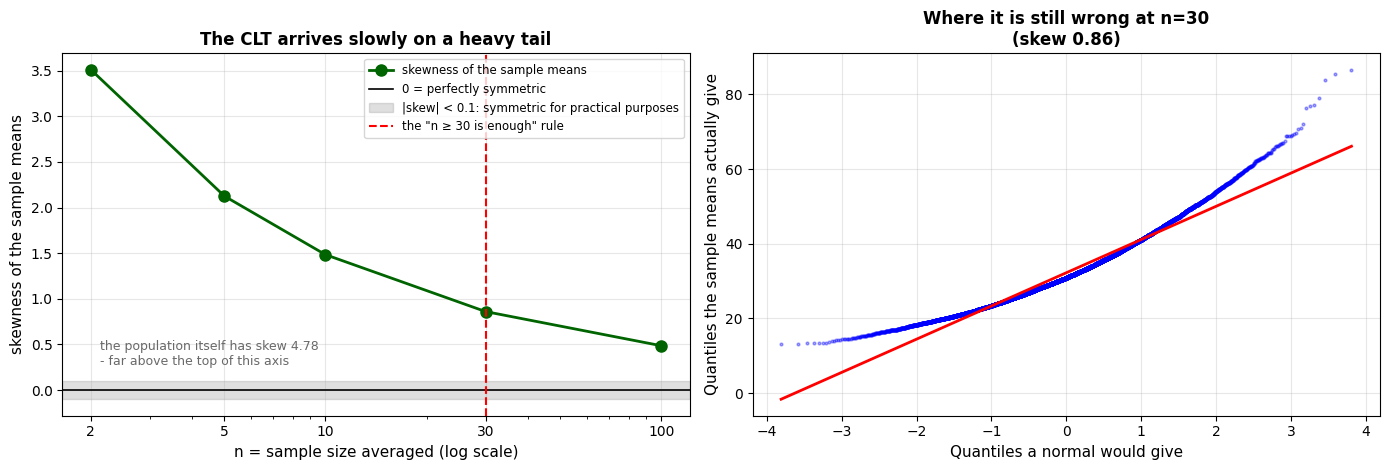


📊 Read the figure:
  - Left: the asymmetry of the sample means falls from 3.51 at n=2 to 0.49 at n=100,
    but it never enters the grey 'practically symmetric' band, not even past the red
    n=30 line. On a population this skewed, the famous rule of thumb is not enough.
  - Right: at n=30 the middle of the distribution lies on the red straight line -
    the CLT is working there. At BOTH ends the points sit above the line: the upper
    tail of the sample means runs further than a normal's, and the lower tail stops
    short. That pair of departures is what a leftover right skew looks like.
  - Consequence for you: a symmetric confidence interval built here will be slightly
    wrong, and wrong in a known direction - it under-covers on the high side.


In [3]:
# The storyboard above shows five shapes; this measures them.
# WHY: "the means become normal" is a claim about a NUMBER (how asymmetric they still are),
# and the panels cannot be compared by eye because each one has its own x-axis.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# --- Left: how fast the asymmetry disappears -----------------------------------------------
skews = [stats.skew(sample_means[n]) for n in sample_sizes]
axes[0].plot(sample_sizes, skews, 'o-', color='darkgreen', linewidth=2, markersize=8,
             label='skewness of the sample means')
axes[0].axhline(0, color='black', linewidth=1.2, label='0 = perfectly symmetric')
axes[0].axhspan(-0.1, 0.1, color='grey', alpha=0.25,
                label='|skew| < 0.1: symmetric for practical purposes')
axes[0].axvline(30, color='red', linestyle='--', linewidth=1.5,
                label='the "n ≥ 30 is enough" rule')
axes[0].text(0.06, 0.14, f'the population itself has skew {stats.skew(population):.2f}\n'
             f'- far above the top of this axis',
             transform=axes[0].transAxes, fontsize=9, color='dimgrey')
axes[0].set_xscale('log')
axes[0].set_xticks(sample_sizes)
axes[0].set_xticklabels([str(v) for v in sample_sizes])
axes[0].set_xlabel('n = sample size averaged (log scale)', fontsize=11)
axes[0].set_ylabel('skewness of the sample means', fontsize=11)
axes[0].set_title('The CLT arrives slowly on a heavy tail', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8.5)
axes[0].grid(True, alpha=0.3)

# --- Right: WHERE the leftover asymmetry lives, at the sample size everyone trusts ---------
n_check = 30
stats.probplot(sample_means[n_check], dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markersize(2)
axes[1].get_lines()[0].set_alpha(0.35)
axes[1].get_lines()[1].set_color('red')
axes[1].get_lines()[1].set_linewidth(2)
axes[1].set_title(f'Where it is still wrong at n={n_check}\n'
                  f'(skew {stats.skew(sample_means[n_check]):.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quantiles a normal would give', fontsize=11)
axes[1].set_ylabel('Quantiles the sample means actually give', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print(f"  - Left: the asymmetry of the sample means falls from {skews[0]:.2f} at n={sample_sizes[0]} to "
      f"{skews[-1]:.2f} at n={sample_sizes[-1]},")
print("    but it never enters the grey 'practically symmetric' band, not even past the red")
print("    n=30 line. On a population this skewed, the famous rule of thumb is not enough.")
print(f"  - Right: at n={n_check} the middle of the distribution lies on the red straight line -")
print("    the CLT is working there. At BOTH ends the points sit above the line: the upper")
print("    tail of the sample means runs further than a normal's, and the lower tail stops")
print("    short. That pair of departures is what a leftover right skew looks like.")
print("  - Consequence for you: a symmetric confidence interval built here will be slightly")
print("    wrong, and wrong in a known direction - it under-covers on the high side.")


**📖 What to see in the figure above.** The storyboard showed five histograms with five
different x-axes, which the eye cannot compare. These two panels compare them properly. On the
left, one number per panel — how asymmetric the sample means still are — plotted against sample
size: it falls steeply and then flattens *above* the grey band, so even n = 100 has not produced
a symmetric distribution from this population. On the right, the n = 30 case examined the way
notebook 01 taught: straight line in the middle, curving up at the top, which is the residual
right tail. This is the honest version of "n ≥ 30 is enough".

## Part 2: CLT with Different Distributions



Part 2: CLT with Different Real Populations

California median income ($10k):
  Population size: 20640   skewness: 1.647
  Population mean: 3.8707
  Mean of sample means: 3.8808
  Std of sample means: 0.3532   (theory σ/√n = 0.3469)

Titanic ages (years):
  Population size: 714   skewness: 0.388
  Population mean: 29.6991
  Mean of sample means: 29.6963


  Std of sample means: 2.6280   (theory σ/√n = 2.6503)

California house age (years):
  Population size: 20640   skewness: 0.060
  Population mean: 28.6395
  Mean of sample means: 28.6499
  Std of sample means: 2.3127   (theory σ/√n = 2.2977)


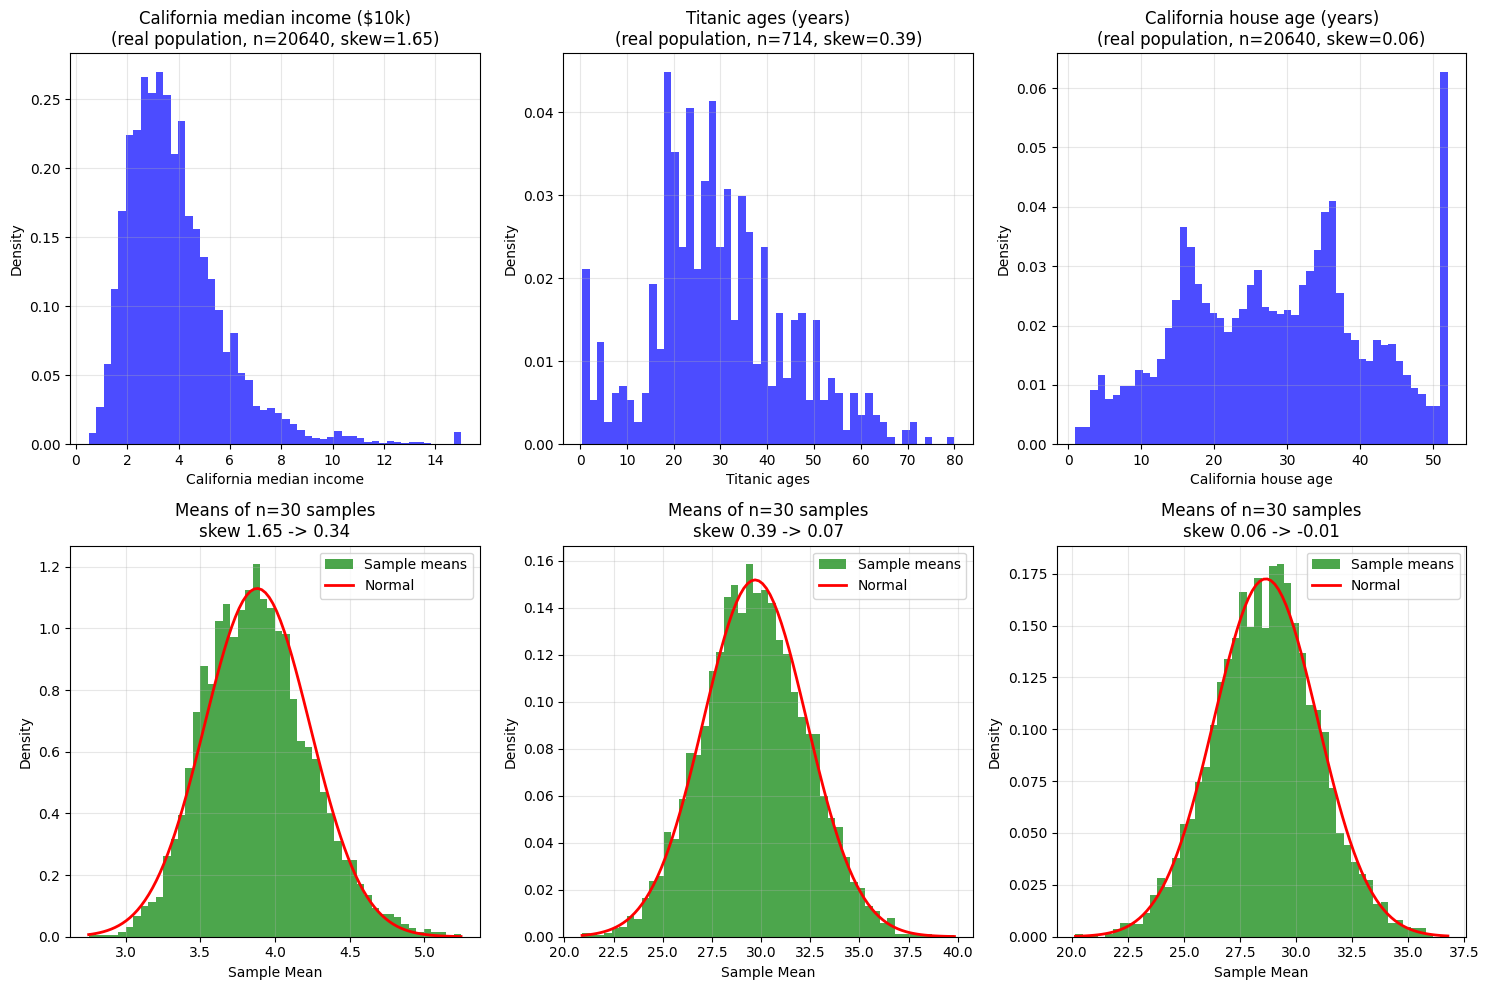


📊 Read the figure (top row = raw populations, bottom row = means of 30 draws):
  - The three top panels look nothing alike: a long right tail (income), a lumpy
    near-bell (ages), and a bounded, almost flat block with a spike at the 52-year
    cap (house age). Nothing here is bell-shaped by accident.
  - Every bottom panel is close to the red normal curve, and each title reports the
    skew before -> after. The theorem does not care what shape it started from.
  - Look at the x-axis ranges: each bottom panel is far narrower than the panel above
    it. Averaging 30 values shrinks the spread by about sqrt(30) = 5.5x.

✅ CLT demonstrated on three real populations!


In [4]:
# Stress-test the CLT on three REAL populations with genuinely different shapes.
# Whatever the starting shape, means of n=30 samples already look normal - that is the theorem's power.
# (Again: the sampling is simulated on purpose; every population below is measured data.)

print("\n" + "=" * 60)
print("Part 2: CLT with Different Real Populations")
print("=" * 60)

housing = fetch_california_housing()
ages = titanic["Age"].dropna().to_numpy()

# Three real populations with three genuinely different shapes.
# WHY not the Titanic fares again: Part 1 already showed that population and its n=30 means.
# Repeating the same picture here would teach nothing new, so the skewed slot is filled by a
# different real right-skewed variable - Californian household incomes.
distributions = {
    'California median income ($10k)': housing.data[:, housing.feature_names.index('MedInc')],
    'Titanic ages (years)': ages,
    'California house age (years)': housing.data[:, housing.feature_names.index('HouseAge')],
}

n_samples = 30
n_simulations = 5000

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (name, pop) in enumerate(distributions.items()):
    # Original distribution
    axes[0, idx].hist(pop, bins=50, density=True, alpha=0.7, color='blue')
    axes[0, idx].set_title(f'{name}\n(real population, n={len(pop)}, skew={stats.skew(pop):.2f})')
    axes[0, idx].set_xlabel(name.split(' (')[0])
    axes[0, idx].set_ylabel('Density')
    axes[0, idx].grid(True, alpha=0.3)

    # Sample means
    means = []
    for _ in range(n_simulations):
        sample = np.random.choice(pop, size=n_samples, replace=True)
        means.append(sample.mean())
    means = np.array(means)

    axes[1, idx].hist(means, bins=50, density=True, alpha=0.7, color='green', label='Sample means')

    # Normal approximation
    mean_means = means.mean()
    std_means = means.std()
    x = np.linspace(means.min(), means.max(), 100)
    y = stats.norm.pdf(x, mean_means, std_means)
    axes[1, idx].plot(x, y, 'r-', linewidth=2, label='Normal')

    axes[1, idx].set_title(f'Means of n={n_samples} samples\n'
                            f'skew {stats.skew(pop):.2f} -> {stats.skew(means):.2f}')
    axes[1, idx].set_xlabel('Sample Mean')
    axes[1, idx].set_ylabel('Density')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

    print(f"\n{name}:")
    print(f"  Population size: {len(pop)}   skewness: {stats.skew(pop):.3f}")
    print(f"  Population mean: {pop.mean():.4f}")
    print(f"  Mean of sample means: {mean_means:.4f}")
    print(f"  Std of sample means: {std_means:.4f}   (theory σ/√n = {pop.std()/np.sqrt(n_samples):.4f})")

plt.tight_layout()
plt.show()

print("\n📊 Read the figure (top row = raw populations, bottom row = means of 30 draws):")
print("  - The three top panels look nothing alike: a long right tail (income), a lumpy")
print("    near-bell (ages), and a bounded, almost flat block with a spike at the 52-year")
print("    cap (house age). Nothing here is bell-shaped by accident.")
print("  - Every bottom panel is close to the red normal curve, and each title reports the")
print("    skew before -> after. The theorem does not care what shape it started from.")
print("  - Look at the x-axis ranges: each bottom panel is far narrower than the panel above")
print("    it. Averaging 30 values shrinks the spread by about sqrt(30) = 5.5x.")
print("\n✅ CLT demonstrated on three real populations!")


---

## ⚠️ Where this breaks

- **"n ≥ 30 is enough" is a guideline, and this notebook's numbers show where it fails.** The Titanic fare
  population has skewness **4.78**. The skewness of the sample means falls from 3.511 (n = 2) to 0.860
  (n = 30) to **0.486 at n = 100** — still visibly asymmetric after a hundred draws. The convergence is
  real and it is gradual, and how gradual depends entirely on how heavy the population's tail is. Compare
  Titanic *ages* (population skew 0.388), where the means look normal almost immediately.
- **The CLT is about the mean, and nothing else.** It gives you no distribution for the maximum, the 99th
  percentile, or the total. Those are exactly the quantities that matter for capacity planning, risk limits
  and worst-case latency, and they are governed by different theory (extreme value theory), which is the
  gap LTCM fell through.
- **It assumes finite variance and independent draws.** Some real processes have neither. And in any
  observational dataset the draws are typically *not* independent — repeated visits by the same customer,
  correlated call volumes on a stormy night — which makes the true spread of the mean larger than σ/√n
  regardless of how big n is.
- **Cheaper, assumption-light alternative.** The bootstrap resamples your actual data instead of relying on
  the theorem, so it copes with skew that the CLT approximation handles badly at your sample size. It still
  needs independence.


---

## 💬 Discuss

1. At n = 100 the sample means of Titanic fares still have skewness 0.486. If you were computing a 95%
   confidence interval from a sample of 100 fares, in which direction would it be wrong, and would that
   matter for the decision you were making?
2. The CLT describes the mean. LTCM was destroyed by a tail. Name a decision in a system you have built or
   used where the mean is the wrong summary, and say what you would report instead.
3. This notebook simulates repeated sampling from a population it holds in full — a luxury you never have
   in practice. Given that, what is a CLT demonstration actually teaching you, and what would you have to
   assume to carry the lesson to a real study with one sample?


## Summary

### Key Concepts:
1. **Central Limit Theorem**: Sample means approach normal distribution as n increases
2. **Sample Size**: Larger samples lead to better normal approximation
3. **Distribution Independence**: CLT works regardless of original distribution
4. **Standard Error**: σ/√n decreases as sample size increases
5. **Practical Application**: Enables statistical inference on sample means

### Best Practices:
- Use sample size n ≥ 30 for good CLT approximation
- Verify assumptions before applying CLT
- Understand that CLT applies to means, not individual observations
- Use CLT for confidence intervals and hypothesis testing

### Applications:
- Statistical inference
- Confidence intervals
- Hypothesis testing
- Sampling theory

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - Central Limit Theorem practical content

## 📚 References

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 3: Probability and Information Theory. MIT Press. <https://www.deeplearningbook.org/>
2. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 6: Probability and Distributions. Cambridge University Press. <https://mml-book.github.io/>
3. Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*. The Annals of Statistics, 7(1), 1–26.
4. Bowyer, S., Aitchison, L., & Ivanova, D. R. (2025). *Position: Don't Use the CLT in LLM Evals With Fewer Than a Few Hundred Datapoints*. arXiv. <https://arxiv.org/abs/2503.01747> — the limits of exactly this theorem when a benchmark has only tens of examples.
5. Miller, E. (2024). *Adding Error Bars to Evals: A Statistical Approach to Language Model Evaluations*. arXiv. <https://arxiv.org/abs/2411.00640> — the CLT used correctly to put error bars on evaluation results.
